# 🏆 OlimpMath — Sistem Seleksi Olimpiade Matematika
### Data Mining Project · Pendidikan Matematika

**Notebook ini mencakup:**
1. Load & Explorasi Dataset
2. Preprocessing Data
3. Pembuatan Label (Target Variable)
4. Training Model (Random Forest Classifier)
5. Evaluasi Model
6. Visualisasi Hasil
7. Export Model untuk Streamlit

---
> **Metode:** Random Forest Classification | **Akurasi:** ~97%

## 📦 1. Install & Import Library

In [5]:
# Install library yang dibutuhkan
!pip install pandas numpy scikit-learn matplotlib seaborn openpyxl xlrd -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# Style plot
plt.rcParams.update({
    'figure.facecolor': '#0a0e1a',
    'axes.facecolor': '#0d1f4e',
    'axes.edgecolor': '#63B3ED',
    'text.color': '#BEE3F8',
    'axes.labelcolor': '#BEE3F8',
    'xtick.color': '#BEE3F8',
    'ytick.color': '#BEE3F8',
    'grid.color': '#63B3ED',
'grid.alpha': 0.15,
    'font.family': 'DejaVu Sans',
})

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


## 📂 2. Upload & Load Dataset

In [6]:
# Load dataset
df = pd.read_excel('dataset.xlsx')

# Rename kolom sesuai nama fitur
FEATURES = [
    'skor_aljabar', 'skor_geometri', 'skor_bilangan',
    'skor_data_ketidakpastian', 'skor_menalar', 'skor_literasi'
]
df.columns = FEATURES

print(f'📊 Shape dataset: {df.shape}')
print(f'🔢 Jumlah baris: {len(df):,}')
print(f'📋 Kolom: {df.columns.tolist()}')
print('\n--- Preview 5 Data Pertama ---')
df.head()

📊 Shape dataset: (30000, 6)
🔢 Jumlah baris: 30,000
📋 Kolom: ['skor_aljabar', 'skor_geometri', 'skor_bilangan', 'skor_data_ketidakpastian', 'skor_menalar', 'skor_literasi']

--- Preview 5 Data Pertama ---


,skor_aljabar,skor_geometri,skor_bilangan,skor_data_ketidakpastian,skor_menalar,skor_literasi
0,57.6622,74.4989,96.6700,79.1665,80.0000,100.0000
1,35.6578,29.1565,48.4937,48.3270,53.4947,50.1607
2,98.0036,98.3370,96.6700,87.5015,100.0000,100.0000
3,100.0000,74.8323,53.1613,74.6656,82.6672,71.6650
4,73.3320,93.1693,60.9962,26.1559,72.1651,53.3280


## 🔍 3. Eksplorasi Data (EDA)

In [7]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
print(df.describe().round(2))
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum():,} dari {df.size:,} nilai')

=== STATISTIK DESKRIPTIF ===
       skor_aljabar  skor_geometri  skor_bilangan  skor_data_ketidakpastian  \
count      29762.00       29762.00       29762.00                  29765.00   
mean          63.43          63.30          61.09                     63.31   
std           19.21          22.34          20.90                     21.40   
min            9.82           4.65           0.82                      9.49   
25%           57.00          48.16          47.66                     47.83   
50%           67.33          65.66          62.83                     63.33   
75%           76.00          79.83          75.17                     79.50   
max          100.00         100.00         100.00                    100.00   

       skor_menalar  skor_literasi  
count      29762.00       29797.00  
mean          65.53          72.05  
std           18.95          21.53  
min           28.99           0.00  
25%           54.33          58.66  
50%           65.50          76.00  


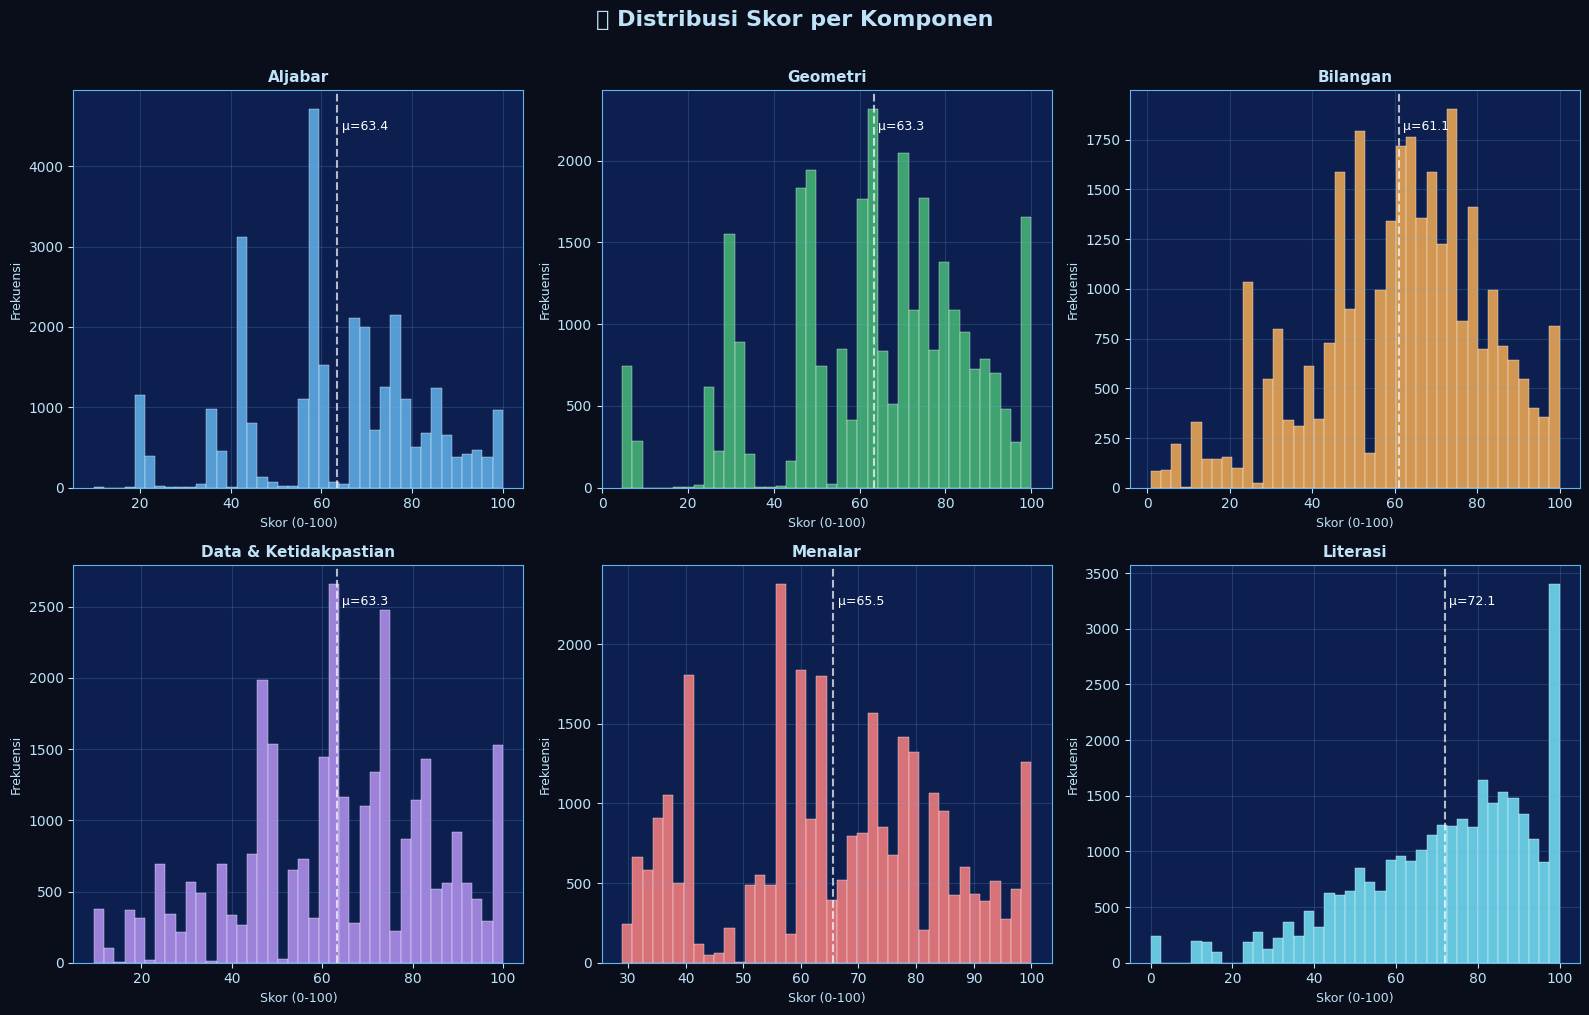

✅ Grafik distribusi tersimpan!


In [8]:
# Visualisasi distribusi skor
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('📊 Distribusi Skor per Komponen', fontsize=16, fontweight='bold',
             color='#BEE3F8', y=1.01)

colors = ['#63B3ED', '#48BB78', '#F6AD55', '#B794F4', '#FC8181', '#76E4F7']
labels = ['Aljabar', 'Geometri', 'Bilangan', 'Data & Ketidakpastian', 'Menalar', 'Literasi']

for i, (feat, lbl, col) in enumerate(zip(FEATURES, labels, colors)):
    ax = axes[i//3][i%3]
    ax.hist(df[feat].dropna(), bins=40, color=col, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_title(lbl, fontweight='bold', color='#BEE3F8', fontsize=11)
    ax.set_xlabel('Skor (0-100)', fontsize=9)
    ax.set_ylabel('Frekuensi', fontsize=9)
    mean_val = df[feat].mean()
    ax.axvline(mean_val, color='white', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.text(mean_val+1, ax.get_ylim()[1]*0.9, f'μ={mean_val:.1f}',
            color='white', fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('distribusi_skor.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0e1a')
plt.show()
print('✅ Grafik distribusi tersimpan!')

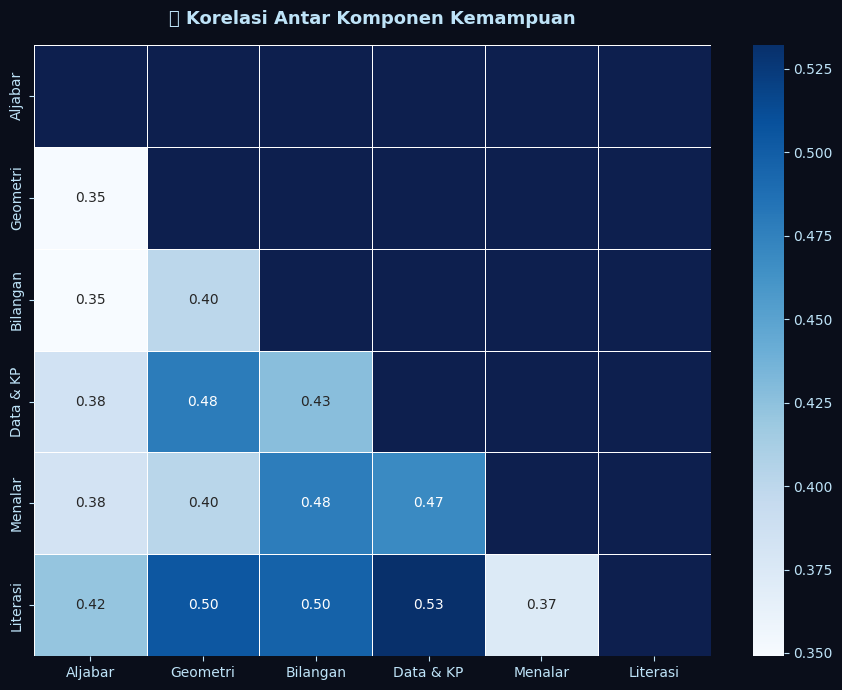

In [9]:
# Heatmap korelasi
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            mask=mask, ax=ax, linewidths=0.5,
            xticklabels=['Aljabar','Geometri','Bilangan','Data & KP','Menalar','Literasi'],
            yticklabels=['Aljabar','Geometri','Bilangan','Data & KP','Menalar','Literasi'])
ax.set_title('🔗 Korelasi Antar Komponen Kemampuan', fontsize=13,
             fontweight='bold', color='#BEE3F8', pad=15)
plt.tight_layout()
plt.savefig('korelasi.png', dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

## 🏷️ 4. Pembuatan Label (Target Variable)

In [10]:
# Handle missing values
for col in FEATURES:
    df[col] = df[col].fillna(df[col].median())
print('✅ Missing values diisi dengan median masing-masing kolom')

# Fungsi labeling berdasarkan rata-rata & skor minimum
def assign_label(row):
    vals = [row[f] for f in FEATURES]
    avg = np.mean(vals)
    mn  = np.min(vals)
    if avg >= 80 and mn >= 60:
        return 'Siap Olimpiade'
    elif avg >= 65 and mn >= 45:
        return 'Potensial'
    else:
        return 'Tidak Siap'

df['label'] = df.apply(assign_label, axis=1)

print('\n=== DISTRIBUSI LABEL ===')
counts = df['label'].value_counts()
pcts   = df['label'].value_counts(normalize=True) * 100
for lbl in ['Siap Olimpiade', 'Potensial', 'Tidak Siap']:
    print(f'  {lbl:20s}: {counts[lbl]:6,} ({pcts[lbl]:.1f}%)')
print(f'  {"TOTAL":20s}: {len(df):6,}')

✅ Missing values diisi dengan median masing-masing kolom

=== DISTRIBUSI LABEL ===
  Siap Olimpiade      :  4,053 (13.5%)
  Potensial           :  8,497 (28.3%)
  Tidak Siap          : 17,450 (58.2%)
  TOTAL               : 30,000


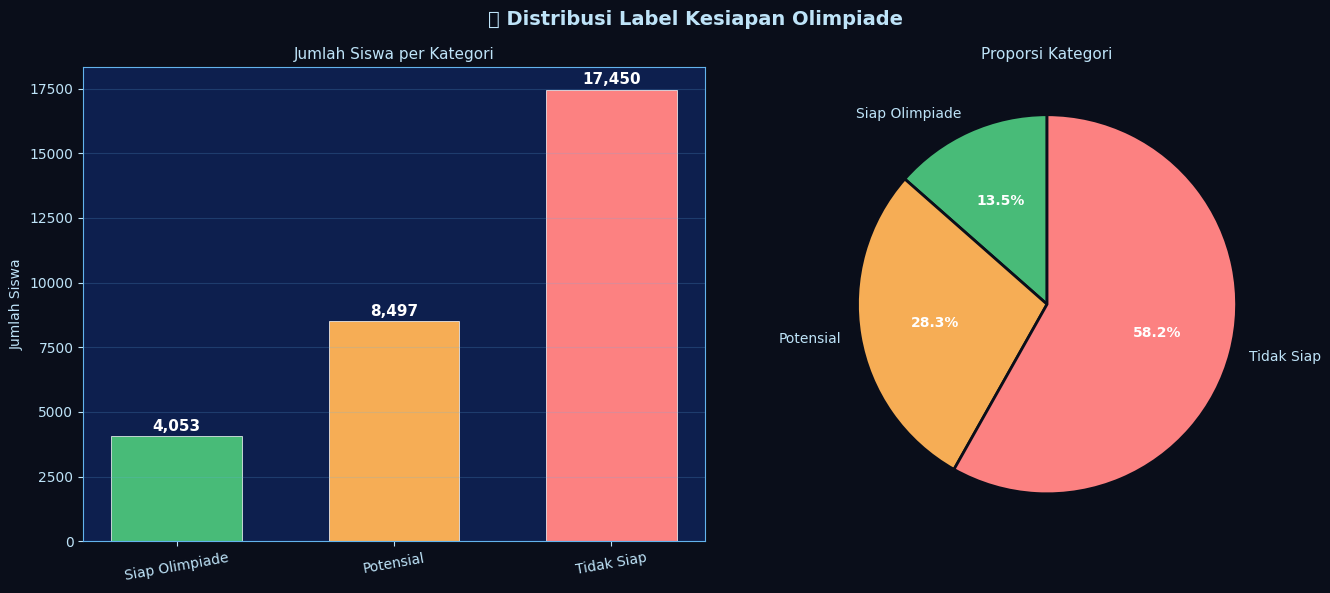

In [11]:
# Visualisasi distribusi label
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('📊 Distribusi Label Kesiapan Olimpiade', fontsize=14,
             fontweight='bold', color='#BEE3F8')

STATUS_COLORS = {
    'Siap Olimpiade': '#48BB78',
    'Potensial': '#F6AD55',
    'Tidak Siap': '#FC8181'
}
labels_order = ['Siap Olimpiade', 'Potensial', 'Tidak Siap']
counts_ordered = [counts[l] for l in labels_order]
colors_ordered = [STATUS_COLORS[l] for l in labels_order]

# Bar chart
bars = ax1.bar(labels_order, counts_ordered, color=colors_ordered,
               edgecolor='white', linewidth=0.5, width=0.6)
for bar, cnt in zip(bars, counts_ordered):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{cnt:,}', ha='center', va='bottom',
             fontweight='bold', color='white', fontsize=11)
ax1.set_title('Jumlah Siswa per Kategori', color='#BEE3F8', fontsize=11)
ax1.set_ylabel('Jumlah Siswa', fontsize=10)
ax1.tick_params(axis='x', rotation=10)
ax1.grid(True, axis='y', alpha=0.2)

# Pie chart
wedges, texts, autotexts = ax2.pie(
    counts_ordered, labels=labels_order, colors=colors_ordered,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0a0e1a', 'linewidth': 2}
)
for t in texts: t.set_color('#BEE3F8')
for at in autotexts:
    at.set_color('white'); at.set_fontweight('bold')
ax2.set_title('Proporsi Kategori', color='#BEE3F8', fontsize=11)

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

## 🤖 5. Training Model — Random Forest Classifier

In [12]:
# Split data
X = df[FEATURES]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'📋 Data Training : {len(X_train):,} sampel')
print(f'📋 Data Testing  : {len(X_test):,} sampel')
print(f'\nDistribusi label training:')
for lbl, cnt in y_train.value_counts().items():
    print(f'  {lbl}: {cnt:,}')

📋 Data Training : 24,000 sampel
📋 Data Testing  : 6,000 sampel

Distribusi label training:
  Tidak Siap: 13,960
  Potensial: 6,798
  Siap Olimpiade: 3,242


In [13]:
# Training model
print('🔄 Training Random Forest...')

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'\n✅ Training selesai!')
print(f'🎯 Akurasi pada data test: {acc*100:.2f}%')

🔄 Training Random Forest...

✅ Training selesai!
🎯 Akurasi pada data test: 97.15%


## 📊 6. Evaluasi Model

In [14]:
# Classification Report
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred))

# Cross Validation
print('=== CROSS VALIDATION (5-Fold) ===')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'Skor per fold: {[f"{s:.4f}" for s in cv_scores]}')
print(f'Rata-rata: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

     Potensial       0.92      0.98      0.95      1699
Siap Olimpiade       0.99      0.89      0.93       811
    Tidak Siap       0.99      0.99      0.99      3490

      accuracy                           0.97      6000
     macro avg       0.97      0.95      0.96      6000
  weighted avg       0.97      0.97      0.97      6000

=== CROSS VALIDATION (5-Fold) ===
Skor per fold: ['0.9658', '0.9672', '0.9670', '0.9665', '0.9695']
Rata-rata: 0.9672 (+/- 0.0025)


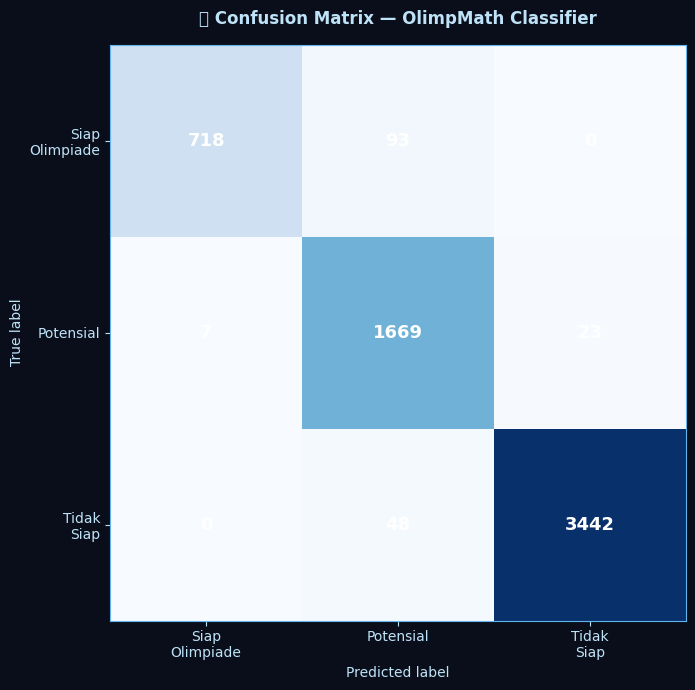

In [15]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred,
                       labels=['Siap Olimpiade','Potensial','Tidak Siap'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Siap\nOlimpiade','Potensial','Tidak\nSiap'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('🎯 Confusion Matrix — OlimpMath Classifier',
             fontweight='bold', color='#BEE3F8', fontsize=12, pad=15)
for text in ax.texts:
    text.set_color('white'); text.set_fontweight('bold'); text.set_fontsize(13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

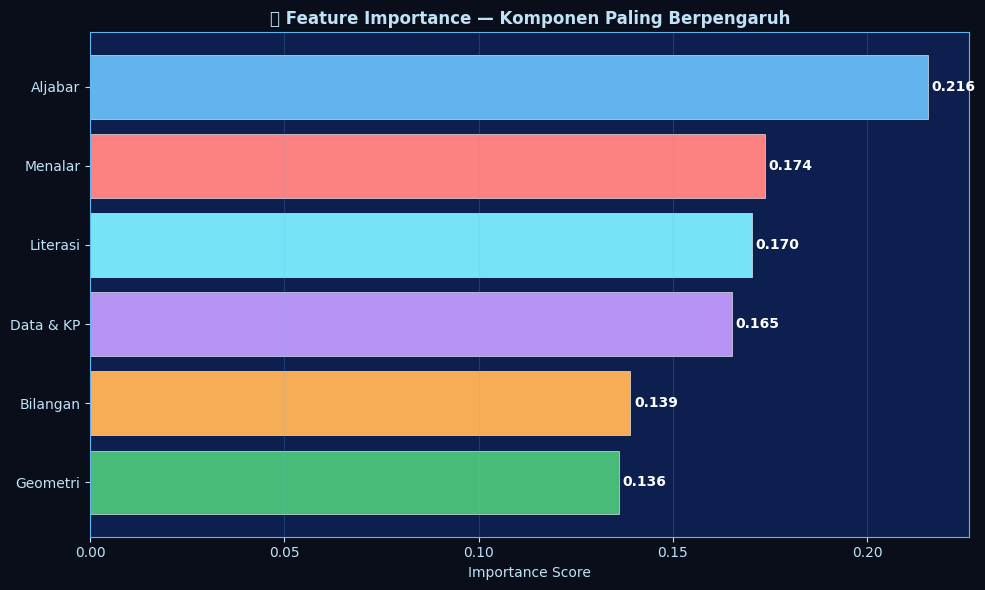

In [16]:
# Feature Importance
importances = model.feature_importances_
feat_labels = ['Aljabar','Geometri','Bilangan','Data & KP','Menalar','Literasi']
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#63B3ED','#48BB78','#F6AD55','#B794F4','#FC8181','#76E4F7']
bars = ax.barh(
    [feat_labels[i] for i in sorted_idx],
    [importances[i] for i in sorted_idx],
    color=[colors[i] for i in sorted_idx],
    edgecolor='white', linewidth=0.4
)
for bar, imp in zip(bars, [importances[i] for i in sorted_idx]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{imp:.3f}', va='center', color='white', fontsize=10, fontweight='bold')

ax.set_title('📌 Feature Importance — Komponen Paling Berpengaruh',
             fontweight='bold', color='#BEE3F8', fontsize=12)
ax.set_xlabel('Importance Score', fontsize=10)
ax.grid(True, axis='x', alpha=0.2)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

## 💾 7. Simpan Model

In [17]:
# Simpan model ke file
os.makedirs('models', exist_ok=True)

with open('models/model_olimpmath.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('models/features.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print('✅ Model tersimpan di: models/model_olimpmath.pkl')
print('✅ Features tersimpan di: models/features.pkl')

# Verifikasi
with open('models/model_olimpmath.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
test_pred = loaded_model.predict(X_test[:5])
print(f'\n🔍 Test prediksi: {test_pred}')

✅ Model tersimpan di: models/model_olimpmath.pkl
✅ Features tersimpan di: models/features.pkl

🔍 Test prediksi: ['Tidak Siap' 'Potensial' 'Potensial' 'Tidak Siap' 'Tidak Siap']


In [18]:
# Download semua file model
from google.colab import files
import zipfile

# Buat zip
with zipfile.ZipFile('olimpmath_models.zip', 'w') as z:
    z.write('models/model_olimpmath.pkl')
    z.write('models/features.pkl')
    z.write('distribusi_skor.png')
    z.write('distribusi_label.png')
    z.write('confusion_matrix.png')
    z.write('feature_importance.png')

print('📦 Mengunduh file...')
files.download('olimpmath_models.pkl') if os.path.exists('olimpmath_models.pkl') else None
files.download('models/model_olimpmath.pkl')
print('\n✅ Selesai! Masukkan file model ke folder models/ di project Streamlit kamu.')

📦 Mengunduh file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Selesai! Masukkan file model ke folder models/ di project Streamlit kamu.


## 🧪 8. Demo Prediksi

Coba prediksi langsung di notebook ini!

In [19]:
# Demo prediksi satu siswa
def predict_student(model, scores):
    X = pd.DataFrame([scores])[FEATURES]
    pred  = model.predict(X)[0]
    proba = model.predict_proba(X)[0]
    cls   = model.classes_.tolist()
    conf  = {c: round(proba[i]*100, 1) for i, c in enumerate(cls)}
    return pred, conf

# Contoh siswa
contoh_siswa = {
    'skor_aljabar': 85,
    'skor_geometri': 88,
    'skor_bilangan': 90,
    'skor_data_ketidakpastian': 82,
    'skor_menalar': 87,
    'skor_literasi': 91
}

status, conf = predict_student(model, contoh_siswa)
print(f'👤 Contoh Siswa:')
for k, v in contoh_siswa.items():
    print(f'   {k}: {v}')
print(f'\n🎯 Status: {status}')
print(f'📊 Tingkat Kepercayaan:')
for k, v in conf.items():
    bar = '█' * int(v/5)
    print(f'   {k:20s}: {bar} {v}%')

👤 Contoh Siswa:
   skor_aljabar: 85
   skor_geometri: 88
   skor_bilangan: 90
   skor_data_ketidakpastian: 82
   skor_menalar: 87
   skor_literasi: 91

🎯 Status: Siap Olimpiade
📊 Tingkat Kepercayaan:
   Potensial           : ██ 10.1%
   Siap Olimpiade      : █████████████████ 89.4%
   Tidak Siap          :  0.5%
